In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

connection = sqlite3.connect("/Users/Raj Gupta/OneDrive/Desktop/datascience/ml project/data/inventory.db")
tables = pd.read_sql_query("select * from sqlite_master where type = 'table'",connection)




In [2]:
purchase_agg_df = pd.read_sql_query('''
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
''', connection)

In [3]:
pd.read_sql_query('''
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
''', connection)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [4]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
SELECT
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)

SELECT
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
ON vi.PONumber = pa.PONumber
""", connection)

In [5]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [ ]:
df.dtypes

In [10]:
def create_invoice_risk_label(row):

    #invoice total mismatch with item-level that
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    #abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

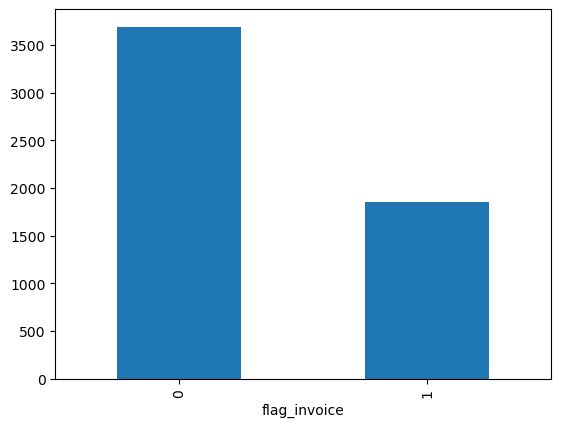

In [14]:
df['flag_invoice'].value_counts().plot(kind = 'bar')
significant_features = []
non_significant_features = []
results = []

In [15]:
metrics = ['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice', 'days_to_pay' 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']